In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import jax
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib
from matplotlib.gridspec import GridSpec
import matplotlib.patches
import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45, Heun
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger
from flax import serialization

# from schmitt_tdvp_blur_jaxmg import TDVPSchmittBlurJAXMg as DynamicsDriver
from schmitt_tdvp_overdispersed import TDVPSchmittOverdispersed
from schmitt_tdvp import TDVPSchmitt

from tfim_exact_majorana import run_ed
import numpy as np

import os
import matplotlib.pyplot as plt

import sys

sys.path.append("../src")

import jax.numpy as jnp

import warnings
warnings.filterwarnings("error", category=jnp.ComplexWarning)


W0620 08:41:56.154805 2287464 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0620 08:41:56.156238 2281910 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


∣NK⟩ Tip: log(ψ) ∈ ℜ → ψ = exp(logψ) ∈ ℜ₊ (real NN gives only positive wave-function).

In [3]:
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values"),
)


def main(N, n_samples_tvmc, driver_type, a, alpha, load_parameter_path=None, t0=0.0, extra_str="", stop_time=1.0):
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    def stop_callback(step,log,driver):
        return driver.t<stop_time
    def get_model():
        return nk.models.RBM(
            alpha=alpha,
            param_dtype=complex,
        )

    def get_vstate(n_samples, power=2):
        seed = 300
        model = get_model()
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples, machine_pow=power
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
        )

        # zero everything
        pars = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), vstate.parameters)

        W = pars["Dense"]["kernel"]
        a = pars["visible_bias"]
        b = pars["Dense"]["bias"]
        n = hilbert.size
        # b + W x = i pi/4 (1 - sum_i x_i), x_i in \{+1,-1\}
        #   -> even x: b + W x = i(k+1) pi /2 ->  cosh(b + W x)= +-1
        #   -> odd x: b + W x = i k pi /2 -> cosh(b + W x)= 0
        W = W.at[:, 0].set(-1j * (np.pi / 4))
        b = b.at[0].set(1j * (np.pi / 4) * n)
        # Repeat to get rid of sign since now
        # psi(x) =  cosh(b_0 + sum_i W_0i x) * cosh(b_1 + sum_i W_1i x)
        #   -> even x: 1
        #   -> odd x: 0
        W = W.at[:, 1].set(-1j * (np.pi / 4))
        b = b.at[1].set(1j * (np.pi / 4) * n)
        # Unit 3 left as zero (neutral)
        pars["Dense"]["kernel"] = W
        pars["Dense"]["bias"] = (
            b + (1 + 1j) * jax.random.uniform(jax.random.key(100), b.shape) * 1e-4
        )
        pars["visible_bias"] = (
            jnp.zeros_like(pars["visible_bias"])
            + (1 + 1j) * jax.random.uniform(jax.random.key(100), a.shape) * N * 1e-4
        )

        # visible_bias stays zero
        vstate.parameters = pars
        return vstate

    # Check energy and parity
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx - sigma_z
    # Hamiltonian
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-1.0, J=1.0)

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z)
        return True

    T = 2.0
    save_times = np.linspace(0.0, T, 40)
    if driver_type == "alpha":
        exp_name = f"alpha_{n_samples_tvmc}_{a:1.2f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity/RBM_{alpha}/{extra_str}{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    resumed = False
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
            resumed = True
    else:
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    vstate = get_vstate(n_samples_tvmc)
    vstate_alpha = get_vstate(n_samples_tvmc, power=a)
    if resumed:
        assert logger.restore_state(vstate)
        # vstate_alpha params are re-synced from vstate by the driver each step.
        T = T - t0
    elif load_parameter_path is not None:
        # Hotstart from another run's snapshot (first run only).
        with open(
            load_parameter_path,
            "rb",
        ) as infile:
            binary_data = infile.read()
            vstate.variables = serialization.from_bytes(vstate.variables, binary_data)
            vstate.variables = jax.tree.map(lambda x: jnp.array(x), vstate.variables)
            # sampler state
            vstate_alpha.variables = serialization.from_bytes(vstate_alpha.variables, binary_data)
            vstate_alpha.variables = jax.tree.map(lambda x: jnp.array(x), vstate_alpha.variables)
        T = T - t0


    # Callbacks
    callbacks = []
    callbacks.append(stop_callback)
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(acceptance_rate_callback)
    if driver_type == "alpha":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    # Set up dynamics
    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}

    if driver_type == "alpha":
        dynamics = TDVPSchmittOverdispersed(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            alpha=a,
            sampling_state=vstate_alpha,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [ ]:
for a in (
    0.5,
    1.0,
):
    main(8, 2**12, "alpha", a, alpha=4, stop_time=2.0)

    load_path = (
        f"./data/TFIM_{8}_parity/RBM_{4}/blur_{2**12}_{0.5:1.2f}/log_params_1.mpack"
    )
    main(
        8,
        2**12,
        "alpha",
        a,
        alpha=4,
        load_parameter_path=load_path,
        t0=0.05,
        extra_str="hotstart_",
        stop_time=2.0,
    )
# main(8, 2**12, "vanilla", a, alpha=4)

Data exists, skipping...
Data exists, skipping...


  0%|          | 0.00/2.00 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 152.186                                                                                                  │
│ ├── (1.0%) | MCState.expect : 1.546 s                                                                           │
│ │   └── (84.6%) | MCState.sample : 1.308 s                                                                      │
│ │       └── (71.1%) | sampling n_discarded samples : 0.930 s                                                    │
│ ├── (8.6%) | MCState.sample : 13.021 s                                                                          │
│ │   └── (74.5%) | sampling n_discarded samples : 9.700 s                                                        │
│ ├── (1.3%) | QGTJacobian_DefaultConstructor : 1.948 s                                                           │
│ │   └── (49.8%) | jacobian : 0.970 s                                  

  0%|          | 0.00/2.00 [00:00<?, ?it/s]

[       nan 0.99999788 0.99999785 ... 0.16616748 0.16526734 0.16550322]
[       nan 0.99999905 0.99999905 ... 0.54214943 0.53151823 0.53193066]


/tmp/ipykernel_2281910/2583621104.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


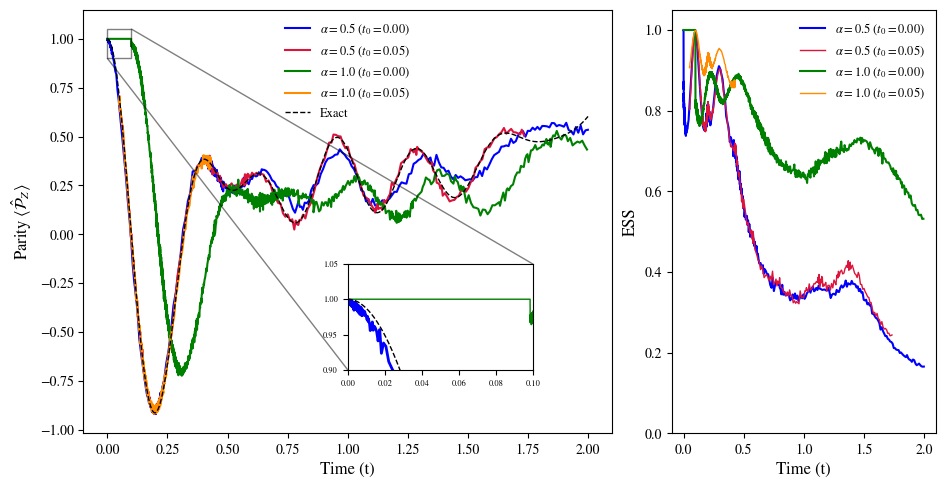

In [4]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
N, alpha_rbm, n_samples = 8, 4, 2**12
times_exact, parity_exact = run_ed(N, h=1.0, J=1.0, T=2.0)

fig = plt.figure(figsize=(11, 5.5))
gs = fig.add_gridspec(1, 2, wspace=0.15, width_ratios=[2, 1])
ax_z = fig.add_subplot(gs[0])
ax_ess = fig.add_subplot(gs[1])

ax_inset = ax_z.inset_axes([0.5, 0.15, 0.35, 0.25])
colors = ['blue', 'crimson', 'green', 'darkorange']
t = 1.75
inset_xlim = [0.0, 0.1]
inset_ylim = [0.9, 1.05]

for i, a in enumerate([0.5, 1.0]):
    # cold start
    sp = f"./data/TFIM_{N}_parity/RBM_{alpha_rbm}/alpha_{n_samples}_{a:1.2f}/"
    lg = Logger(path=sp, fields=fields_to_track)
    if lg.restore():
        ts = np.array(lg.data["t"]["values"])
        par = np.array(lg.data["parity"]["Mean"]).real
        ess = np.array(lg.data["ess_bridge"]["values"])
        print(ess)
        ax_z.plot(ts, par, color=colors[2*i], label=fr"$\alpha={a}$ ($t_0=0.00$)")
        ax_inset.plot(ts, par, color=colors[2*i], lw=2 if i == 0 else 1)
        ax_ess.plot(ts, ess, color=colors[2*i], label=fr"$\alpha={a}$ ($t_0=0.00$)")

    # hot start
    sp = f"./data/TFIM_{N}_parity/RBM_{alpha_rbm}/hotstart_alpha_{n_samples}_{a:1.2f}/"
    lg = Logger(path=sp, fields=fields_to_track)
    if lg.restore():
        ts = np.array(lg.data["t"]["values"])
        par = np.array(lg.data["parity"]["Mean"]).real
        ess = np.array(lg.data["ess_bridge"]["values"])
        idx = np.where(ts < t)[0][-1]
        ax_z.plot(ts[:idx], par[:idx], color=colors[2*i+1], label=fr"$\alpha={a}$ ($t_0=0.05$)")
        ax_inset.plot(ts[:idx], par[:idx], color=colors[2*i+1], lw=1)
        ax_ess.plot(ts[:idx], ess[:idx], color=colors[2*i+1], label=fr"$\alpha={a}$ ($t_0=0.05$)", lw=1)

ax_z.plot(times_exact, np.real(parity_exact), "k--", lw=1, label="Exact")
ax_inset.plot(times_exact, np.real(parity_exact), "k--", lw=1)

ax_inset.set_xlim(inset_xlim)
ax_inset.set_ylim(inset_ylim)
ax_inset.tick_params(labelsize=6)
ax_z.indicate_inset_zoom(ax_inset, edgecolor="black")

ax_z.set_xlabel("Time (t)", fontsize=12)
ax_z.set_ylabel(r"Parity $\langle \hat{\mathcal{P}}_Z\rangle$", fontsize=12)
ax_z.legend(fontsize=9, frameon=False)

ax_ess.set_xlabel("Time (t)", fontsize=12)
ax_ess.set_ylabel("ESS", fontsize=12)
# ax_ess.set_xscale("log")
ax_ess.set_ylim([0, 1.05])
ax_ess.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("Fig5_overdispersed.pdf", bbox_inches="tight")
plt.show()
